Code taken from:
https://umap-learn.readthedocs.io/en/latest/basic_usage.html

Install the umap module with conda:
`conda install -c conda-forge umap-learn`

or with pip: 
`pip install umap-learn`

In [1]:
import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
%matplotlib inline
import keras

import umap

from io import BytesIO
from PIL import Image
import base64

In [2]:
import json, sys
from scipy.io import  wavfile
from IPython import display

import str_ww_util as util
import get_dataset
import keras_model as models

from IPython import display


In [3]:
sns.set(style='white', context='notebook', rc={'figure.figsize':(14,10)})

In [4]:
rng = np.random.default_rng(2024)

In [5]:
from get_dataset import get_data, get_file_lists, get_data_config

In [6]:
# jupyter will pass an extra -f=<tmp_file> arg, which throws an 
# unrecognized argument error
sys.argv = sys.argv[0:1] 

Flags = util.parse_command("evaluate")

In [7]:
notebook_mode = "short_inference" # "short_inference" OR "inference" OR "short_training" OR "full_training"

if notebook_mode == "inference": 
  load_pretrained_model = True
  save_model = False
elif notebook_mode == "short_inference": 
  load_pretrained_model = True
  save_model = False
  Flags.num_samples_training = 2000
  Flags.num_samples_validation = 1000
  Flags.num_samples_test = 1000
else:
  # Or make custom settings here
  pass

# 'trained_models/str_ww_model.h5' is the default save path for train.py
# pretrained_model_path = 'trained_models/str_ww_ref_model.h5' # path to load from if load_pretrained_model is True
pretrained_model_path = 'trained_models/str_ww_ref_model.h5' # path to load from if load_pretrained_model is True

samp_freq = Flags.sample_rate
label_list=['marvin', 'silent', 'other']

In [8]:
try:
    with open('streaming_config.json', 'r') as fpi:
        streaming_config = json.load(fpi)
    Flags.data_dir = streaming_config['speech_commands_path']
except:
    raise RuntimeError("""
        In this directory, copy streaming_config_template.json to streaming_config.json
        and edit it to point to the directories where you have the speech commands dataset
        and (optionally) the MUSAN noise data set.
        """)
Flags.bg_path = Flags.data_dir

In [9]:
ds_train, ds_test, ds_val = get_dataset.get_all_datasets(Flags)

Using seed 1091069196
About to get val data. 

2025-01-07 08:50:57.256999: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2025-01-07 08:50:57.257019: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2025-01-07 08:50:57.257023: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2025-01-07 08:50:57.257047: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-01-07 08:50:57.257059: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Building dataset with 200 targets, 100 silent, and 700 other.
About to get train data. Building dataset with 400 targets, 200 silent, and 1400 other.
About to get test data. Building dataset with 200 targets, 100 silent, and 700 other.
Done building datasets


In [10]:
## This could probably be faster if we pre-allocate x_train, y_train  
## based on ds_train.cardinality() and then fill in the values.
x1, y1 = ds_train.as_numpy_iterator().next()
x_shape = x1.shape[1:]
y_shape = y1.shape[1:]
x_train = np.zeros((0,)+x_shape)
y_train = np.zeros((0,)+y_shape)
for x,y in ds_train:
  x_train = np.concatenate((x_train,x), axis=0)
  y_train = np.concatenate((y_train,y), axis=0)

y_train = np.argmax(y_train, axis=1) # convert from one hot to index

In [11]:
print(f"Loading pretrained model from {pretrained_model_path}")
model = keras.models.load_model(pretrained_model_path)
model.summary()

Loading pretrained model from trained_models/str_ww_ref_model.h5


Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 30, 1, 40)]       0         
                                                                 
 depthwise_conv2d (Depthwis  (None, 28, 1, 40)         120       
 eConv2D)                                                        
                                                                 
 conv2d (Conv2D)             (None, 28, 1, 128)        5120      
                                                                 
 batch_normalization (Batch  (None, 28, 1, 128)        512       
 Normalization)                                                  
                                                                 
 activation (Activation)     (None, 28, 1, 128)        0         
                                                                 
 dropout (Dropout)           (None, 28, 1, 128)        0     

In [12]:
use_features = True
feature_layer = -4

specgrams = x_train.squeeze()
if use_features:
  feature_model = keras.Model(inputs=model.input, outputs=model.layers[feature_layer].output)
  feature_data = feature_model(x_train)
  feature_model.summary()  
  feature_data = feature_data.numpy()
  print(f"Using layer {feature_layer}, {model.layers[feature_layer].name},",
        f"type {model.layers[feature_layer].__class__.__name__}")
else:
  print(f"Using input spectrograms")
  feature_data = specgrams

feature_data = feature_data.reshape(feature_data.shape[0], -1)


Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 30, 1, 40)]       0         
                                                                 
 depthwise_conv2d (Depthwis  (None, 28, 1, 40)         120       
 eConv2D)                                                        
                                                                 
 conv2d (Conv2D)             (None, 28, 1, 128)        5120      
                                                                 
 batch_normalization (Batch  (None, 28, 1, 128)        512       
 Normalization)                                                  
                                                                 
 activation (Activation)     (None, 28, 1, 128)        0         
                                                                 
 dropout (Dropout)           (None, 28, 1, 128)        0     

In [13]:
reducer = umap.UMAP(random_state=42)
reducer.fit(feature_data)

/Users/jeremy/miniforge3/envs/jh_main/lib/python3.11/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


UMAP(random_state=42, tqdm_kwds={'bar_format': '{desc}: {percentage:3.0f}%| {bar} {n_fmt}/{total_fmt} [{elapsed}]', 'desc': 'Epochs completed', 'disable': True})

In [14]:
embedding = reducer.transform(feature_data)
# Verify that the result of calling transform is
# idenitical to accessing the embedding_ attribute
assert(np.all(embedding == reducer.embedding_))
embedding.shape

(2000, 2)

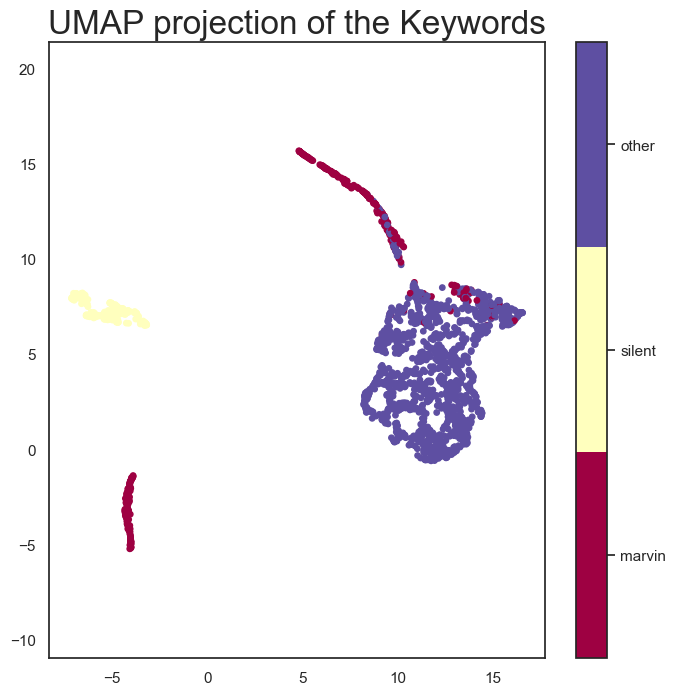

In [15]:
plt.figure(figsize=(8,8))
num_samples = x_train.shape[0]
idx = slice(0,num_samples)
plt.scatter(embedding[idx, 0], embedding[idx, 1], c=y_train[idx], cmap='Spectral', s=15)
plt.gca().set_aspect('equal', 'datalim')
hCBar = plt.colorbar(boundaries=np.arange(4)-0.5)
hCBar.set_ticks(np.arange(3))
hCBar.set_ticklabels(label_list)
plt.title('UMAP projection of the Keywords', fontsize=24);

In [16]:
def embeddable_image(data):
    # scale from [0.0,1.0] => [0,255], invert (so large => black), and cast to uint8
    img_data = (255 * (1.0-data.T)).astype(np.uint8)
    image = Image.fromarray(img_data, mode='L').resize((64, 64), Image.BICUBIC)
    buffer = BytesIO()
    image.save(buffer, format='png')
    for_encoding = buffer.getvalue()
    return 'data:image/png;base64,' + base64.b64encode(for_encoding).decode()

In [17]:
from bokeh.plotting import figure, show, output_notebook
from bokeh.models import HoverTool, ColumnDataSource, CategoricalColorMapper
from bokeh.palettes import Spectral10

In [18]:
# notebook output does not work with the zoom tools for me, so let it render on a separate tab
output_notebook() 

Loading BokehJS ...

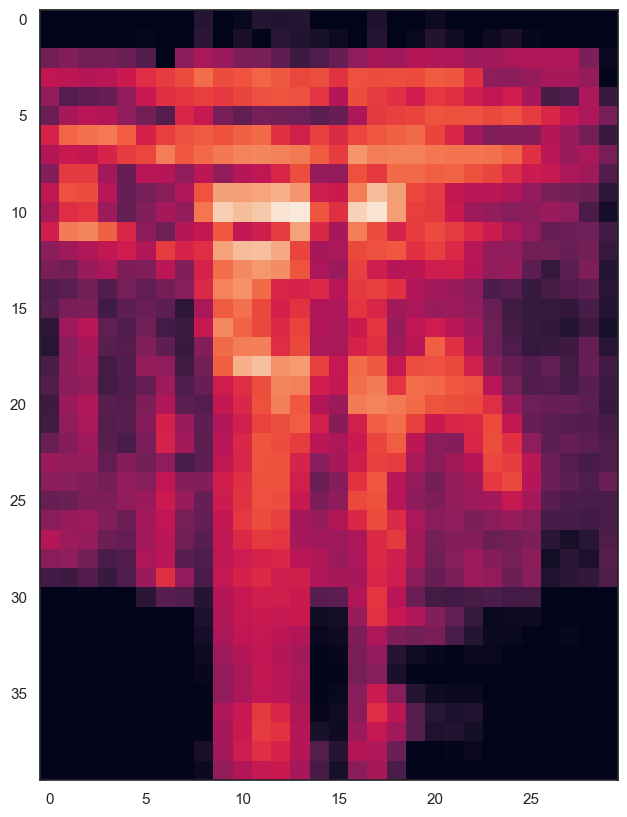

In [19]:
plt.imshow(specgrams[0].T)

''
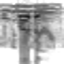

In [20]:
embeddable_image(specgrams[0])

In [21]:
data_df = pd.DataFrame(embedding, columns=('x', 'y'))
#y_train[idx], label_list
data_df['class_name'] = [label_list[c] for c in y_train]
data_df['image'] = list(map(embeddable_image, specgrams))

In [22]:
!pwd

/Users/jeremy/dev/tiny_mlperf/tiny_jhsyn/benchmark/training/streaming_wakeword


In [25]:
datasource = ColumnDataSource(data_df)
color_mapping = CategoricalColorMapper(factors=label_list,
                                       palette=["red", "green", "blue"])

plot_figure = figure(
    title='UMAP projection of the Digits dataset',
    width=600, # was plot_width=600,
    height=600, # was plot_height=600, 
    tools=(['pan', 'reset','wheel_zoom'])  # can replace wheel_zoom with zoom_in, zoom_out
)

plot_figure.add_tools(HoverTool(tooltips="""
<div>
    <div>
        <img src='@image' style='float: left; margin: 5px 5px 5px 5px'/>
    </div>
    <div>
        <span style='font-size: 16px; color: #224499'>Class:</span>
        <span style='font-size: 18px'>@class_name</span>
    </div>
</div>
"""))

plot_figure.scatter(
    'x',
    'y',
    source=datasource,
    color=dict(field='class_name', transform=color_mapping),
    line_alpha=0.6,
    fill_alpha=0.6,
    size=6
)
show(plot_figure)

In [26]:
wav_sampling_freq, long_wav = wavfile.read("long_wav.wav")
assert wav_sampling_freq == samp_freq
t = np.arange(len(long_wav))/samp_freq
print(f"min/max of long wav = {np.min(long_wav)} / {np.max(long_wav)}")
long_wav = long_wav / 2**15 # scale into [-1.0, +1.0] range

ww_windows_file = 'long_wav_ww_windows.json' # start/stop points of wakewords in a list
with open(ww_windows_file, 'r') as fpi:
  ww_windows = json.load(fpi)
  
# construct waveform that shows when wakeword is present
ww_present = np.zeros(len(long_wav))
for t_start, t_stop in ww_windows:
  idx_start = int(t_start*samp_freq)
  idx_stop  = int(t_stop*samp_freq)
  ww_present[idx_start:idx_stop] = 1

min/max of long wav = -32768 / 27775


In [27]:
## build a feature extractor that can operate on longer waveforms.
## this one can operate on waveforms up to len(long_wav)
data_config_long = get_dataset.get_data_config(Flags, 'training')

with open("data_config_nb.json", "w") as fpo:
    json.dump(data_config_long, fpo, indent=4)
              
# long_wav = long_wav / np.max(np.abs(long_wav)) # scale into [-1.0, +1.0] range
t = np.arange(len(long_wav))/samp_freq

feature_extractor_long = get_dataset.get_lfbe_func(data_config_long)
# the feature extractor needs a label (in 1-hot format), but it doesn't matter what it is
# long_spec = feature_extractor_long({'audio':long_wav, 'label':[0.0, 0.0, 0.0]})['audio'].numpy()

# long_spec = feature_extractor_long(np.expand_dims(long_wav, 0)).numpy()
long_spec = feature_extractor_long(long_wav).numpy()

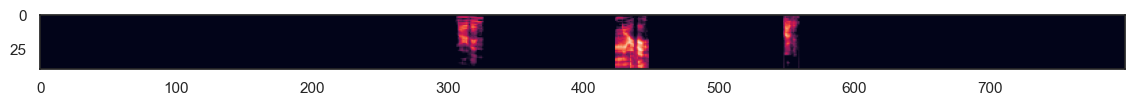

In [31]:
plt.imshow(long_spec.T.squeeze()[:,200:1000])

19200000


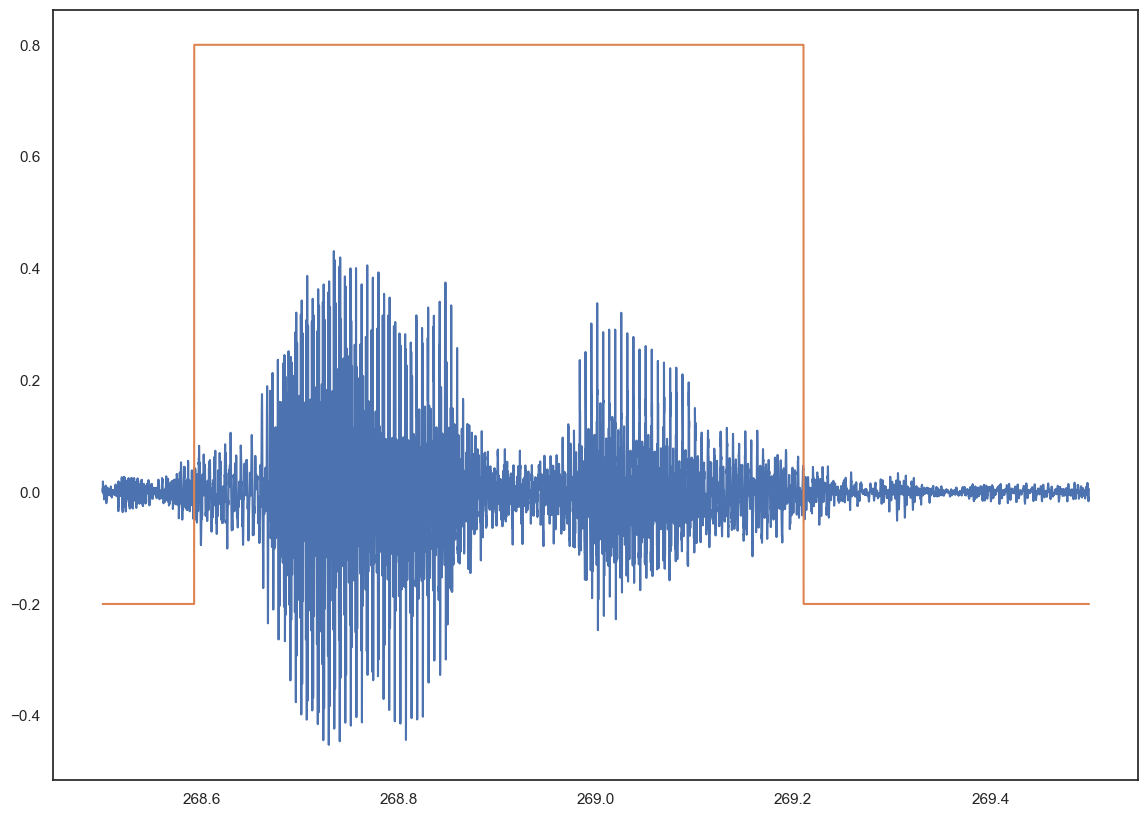

In [42]:
print(len(long_wav))
# idx = slice(265*16000,275*16000)
idx = slice(int(268.5*16000),int(269.5*16000))
plt.plot(t[idx], long_wav[idx], t[idx], ww_present[idx]-0.2)

In [50]:
print(long_spec.shape)
print(long_wav.shape)
samp_freq

(37499, 1, 40)
(19200000,)


16000

In [84]:
stride_samples = int(Flags.window_stride_ms*samp_freq/1000)
clip_len_samples = 16000
print(stride_samples)
ww_present_strided = np.lib.stride_tricks.sliding_window_view(ww_present, clip_len_samples)[0::stride_samples,:]
# sets window_length=8, window_stride=4
# sliding_window_view(np.arange(32), 8)[0::4,:]


512


In [65]:
ww_present_strided.shape

(37469, 16000)

In [69]:
ww_present_strided.shape
ww_present_subsampled = np.zeros(ww_present_strided.shape[0])
for i in range(len(ww_present_subsampled)):
  if ww_present_strided[i,0] == 1 or ww_present_strided[i,-1] == 1:
    # ww still in progress at beginning or end of clip, so not clear
    # if it should 
    ww_present_subsampled[i] = 0.5
  elif np.max(ww_present_strided[i,:]) == 1:
    ww_present_subsampled[i] = 1
  else:
    ww_present_subsampled[i] = 0
    


In [85]:
Flags.window_stride_ms
# sample_stride
# t_spec= np.arange(long_spec.shape[0])*(Flags.window_stride_ms/1000)
# spec_clip = long_spec.T.squeeze()[:,idx]
# spec_clip.shape
print(long_spec.shape)

(37499, 1, 40)


In [91]:
# spec_clip = long_spec.squeeze().T[:,spec_idx]
spec_clip = long_spec.squeeze().T

stride_samples

512

spec_clip.shape=(40, 0)


ValueError: For X (41) and Y (0) with flat shading, A should have shape (-1, 40, 3) or (-1, 40, 4) or (-1, 40) or (-40,), not (0, 40)

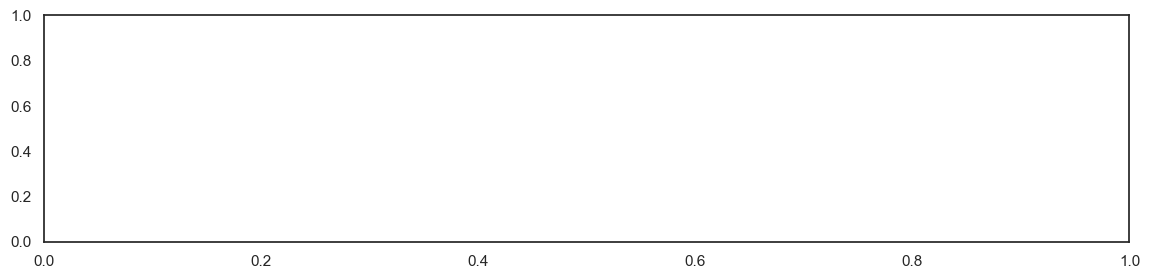

In [100]:
wav_idx = slice(265*Flags.sample_rate,270*Flags.sample_rate)
t_wav= np.arange(wav_idx.start, wav_idx.stop)/Flags.sample_rate

spec_idx = slice(int(wav_idx.start/stride_samples), int(wav_idx.stop/stride_samples))
spec_clip = long_spec.squeeze().T[:,spec_idx]
print(f"spec_clip.shape={spec_clip.shape}")
t_spec= np.arange(spec_clip.shape[0])*(Flags.window_stride_ms/1000)


plt.subplot(3,1,1)
# plt.imshow(spec_clip, origin="lower", aspect="auto", cmap="jet")    
mels = np.arange(spec_clip.shape[-1])
plt.pcolormesh(t_spec, mels, spec_clip.squeeze().T)


plt.subplot(3,1,2)
plt.plot(t[wav_idx], long_wav[wav_idx], t[wav_idx], ww_present[wav_idx]-0.2)

plt.subplot(3,1,3)
# plt.imshow(spec_clip, origin="lower", aspect="auto", cmap="jet")    
mels = np.arange(spec_clip.shape[-1])
long_spec = feature_extractor_long(long_wav[wav_idx]).numpy()
plt.pcolormesh(t_spec, mels, long_spec.squeeze())


In [96]:
data_config_long = get_dataset.get_data_config(Flags, 'training')
feature_extractor_long = get_dataset.get_lfbe_func(data_config_long)

In [98]:
long_spec.shape

(155, 1, 40)

In [99]:
spec_clip.shape

(40, 156)